## Machine Learning Analysis

This notebook predicts divorce status using demographic and socio-economic variables from the IPUMS USA dataset. The model is not meant to explain divorce perfectly. The goal is to test whether the selected variables contain useful predictive information and to compare different classification models.

Because the target variable is imbalanced, I evaluate the models with accuracy, precision, recall, F1 score, ROC-AUC, and confusion matrices instead of relying only on accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

## 1. Load Data

In [2]:
DATA_PATH = "data/usa_00001.csv"

df = pd.read_csv(DATA_PATH)
print("Original shape:", df.shape)
df.head()

Original shape: (3405809, 20)


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,PERWT,SEX,AGE,MARST,EDUC,EDUCD,EMPSTAT,EMPSTATD,INCWAGE,POVERTY
0,2023,202301,1,2023010000113,6.0,2023000000011,41,280201,3,1,6.0,2,86,5,6,63,3,30,0,0
1,2023,202301,2,2023010000180,27.0,2023000000021,41,10001,3,1,27.0,1,60,6,6,63,3,30,0,0
2,2023,202301,3,2023010000181,47.0,2023000000031,41,40201,4,1,47.0,1,20,6,7,71,3,30,0,0
3,2023,202301,4,2023010000250,11.0,2023000000041,41,270201,3,1,11.0,2,13,6,2,26,0,0,999999,0
4,2023,202301,5,2023010000340,57.0,2023000000051,41,280201,4,1,57.0,1,18,6,6,65,3,30,2500,0


## 2. Cleaning and Target Variable

I keep adults only and remove never-married people. This makes the classification task more meaningful because never-married people cannot be classified as divorced in the same social context.

In [3]:
if "AGE" in df.columns:
    df = df[df["AGE"] >= 18].copy()

if "MARST" not in df.columns:
    raise ValueError("MARST column is needed for the target variable.")

# MARST = 6 means never married in IPUMS coding.
df = df[df["MARST"] != 6].copy()

# Divorced or separated are coded as 1.
df["divorced"] = df["MARST"].isin([3, 4]).astype(int)

print("Cleaned shape:", df.shape)
print(df["divorced"].value_counts(normalize=True).round(3))

Cleaned shape: (2002392, 21)
divorced
0    0.827
1    0.173
Name: proportion, dtype: float64


## 3. Feature Engineering

The dataset includes demographic, employment, education, and income-related variables from IPUMS. I also created several engineered features such as grouped variables, interaction features, and transformed income variables to capture more complex socio-economic patterns related to divorce status.

In [4]:
# Make sure numeric columns are actually numeric when they exist.
for col in ["AGE", "SEX", "EDUC", "EMPSTAT", "INCWAGE", "POVERTY", "WKSWORK2", "UHRSWORK"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Income features
if "INCWAGE" in df.columns:
    df.loc[df["INCWAGE"] < 0, "INCWAGE"] = np.nan
    df["INCWAGE"] = df["INCWAGE"].fillna(0)
    df["log_income"] = np.log1p(df["INCWAGE"])

    try:
        df["income_group"] = pd.qcut(
            df["INCWAGE"],
            q=4,
            labels=["low", "lower_middle", "upper_middle", "high"],
            duplicates="drop"
        ).astype(str)
    except ValueError:
        df["income_group"] = "unknown"

# Age features
if "AGE" in df.columns:
    df["young"] = (df["AGE"] <= 25).astype(int)
    df["age_squared"] = df["AGE"] ** 2
    df["age_group"] = pd.cut(
        df["AGE"],
        bins=[17, 25, 35, 45, 55, 65, 100],
        labels=["18_25", "26_35", "36_45", "46_55", "56_65", "66_plus"]
    ).astype(str)

# Education and employment features
if "EDUC" in df.columns:
    df["high_education"] = (df["EDUC"] >= 10).astype(int)

if "EMPSTAT" in df.columns:
    df["employed"] = (df["EMPSTAT"] == 1).astype(int)

# Poverty feature, if the extract has it
if "POVERTY" in df.columns:
    df["POVERTY"] = df["POVERTY"].fillna(df["POVERTY"].median())
    df["low_poverty_ratio"] = (df["POVERTY"] < 150).astype(int)

# Work intensity feature, if the extract has it
if "UHRSWORK" in df.columns:
    df["UHRSWORK"] = df["UHRSWORK"].fillna(0)
    df["full_time"] = (df["UHRSWORK"] >= 35).astype(int)

# Interaction features. These are simple but useful for this question.
if {"SEX", "log_income"}.issubset(df.columns):
    df["sex_income_interaction"] = df["SEX"] * df["log_income"]

if {"AGE", "log_income"}.issubset(df.columns):
    df["age_income_interaction"] = df["AGE"] * df["log_income"]

if {"EDUC", "log_income"}.issubset(df.columns):
    df["education_income_interaction"] = df["EDUC"] * df["log_income"]

print("Feature engineering finished.")
print("Shape:", df.shape)

Feature engineering finished.
Shape: (2002392, 32)


## 4. Select Features

I include the original variables and engineered variables that are available in the dataset. The code checks for missing columns so that the notebook can still run if the extract does not include every optional IPUMS variable.

In [5]:
numeric_features = [
    "AGE", "SEX", "EDUC", "EMPSTAT", "INCWAGE", "log_income", "young", "age_squared",
    "high_education", "employed", "POVERTY", "low_poverty_ratio", "WKSWORK2", "UHRSWORK",
    "full_time", "sex_income_interaction", "age_income_interaction", "education_income_interaction"
]

categorical_features = [
    "age_group", "income_group", "RACE", "CLASSWKR"
]

numeric_features = [col for col in numeric_features if col in df.columns]
categorical_features = [col for col in categorical_features if col in df.columns]

features = numeric_features + categorical_features

df_model = df[features + ["divorced"]].copy()

# Fill missing values in a simple and reproducible way.
for col in numeric_features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

for col in categorical_features:
    df_model[col] = df_model[col].fillna("unknown").astype(str)

print("Number of features before one-hot encoding:", len(features))
print(features)
print(df_model.shape)

Number of features before one-hot encoding: 17
['AGE', 'SEX', 'EDUC', 'EMPSTAT', 'INCWAGE', 'log_income', 'young', 'age_squared', 'high_education', 'employed', 'POVERTY', 'low_poverty_ratio', 'sex_income_interaction', 'age_income_interaction', 'education_income_interaction', 'age_group', 'income_group']
(2002392, 18)


## 5. Sample Data for Speed

The full data is large. I use a 10,000 row sample to keep the notebook easy to run, while still having enough observations for model comparison.

In [6]:
SAMPLE_SIZE = 10000

if len(df_model) > SAMPLE_SIZE:
    df_sample = df_model.sample(n=SAMPLE_SIZE, random_state=42)
else:
    df_sample = df_model.copy()

X = df_sample[features]
y = df_sample["divorced"]

print("Sample shape:", df_sample.shape)
print(y.value_counts(normalize=True).round(3))

Sample shape: (10000, 18)
divorced
0    0.826
1    0.174
Name: proportion, dtype: float64


## 6. Train-Test Split and Preprocessing

Numeric variables are standardized. Categorical variables are one-hot encoded.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8000, 17)
Test shape: (2000, 17)


## 7. Train Models

I compare Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Logistic Regression is useful as a baseline. Random Forest and Gradient Boosting can capture more flexible relationships.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": auc
    })

    trained_models[name] = pipe

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Random Forest,0.7545,0.342222,0.441261,0.385482,0.682860
0,Logistic Regression,0.6455,0.272152,0.616046,0.377524,0.696680
2,Decision Tree,0.6555,0.270270,0.573066,0.367309,0.666180
1,KNN,0.7990,0.333333,0.151862,0.208661,0.618623
4,Gradient Boosting,0.8255,0.500000,0.060172,0.107417,0.692012


## 8. Classification Reports


In [9]:
for name, pipe in trained_models.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    y_pred_model = pipe.predict(X_test)
    print(classification_report(y_test, y_pred_model, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      1651
           1       0.27      0.62      0.38       349

    accuracy                           0.65      2000
   macro avg       0.58      0.63      0.56      2000
weighted avg       0.78      0.65      0.69      2000

KNN
              precision    recall  f1-score   support

           0       0.84      0.94      0.88      1651
           1       0.33      0.15      0.21       349

    accuracy                           0.80      2000
   macro avg       0.59      0.54      0.55      2000
weighted avg       0.75      0.80      0.77      2000

Decision Tree
              precision    recall  f1-score   support

           0       0.88      0.67      0.76      1651
           1       0.27      0.57      0.37       349

    accuracy                           0.66      2000
   macro avg       0.58      0.62      0.57      2000
weighted avg       0.78      0.66   

## 9. Model Comparison Plot

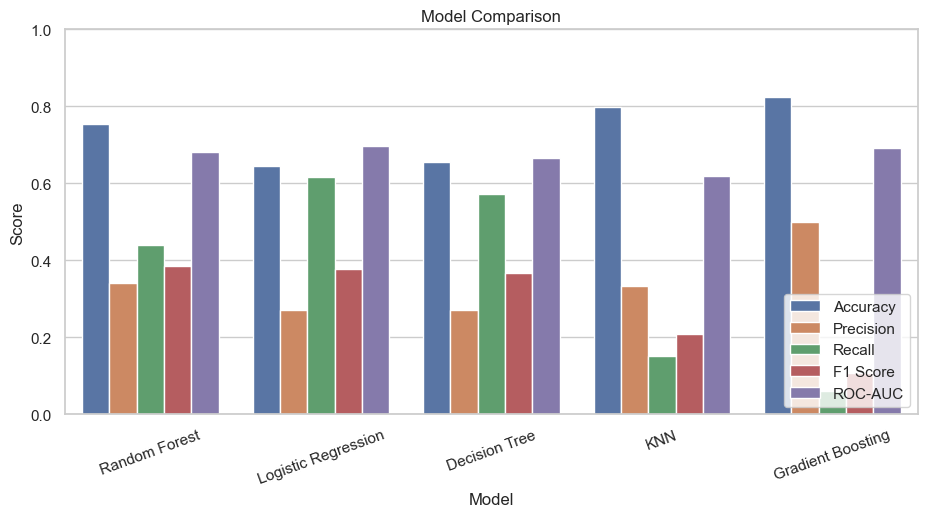

In [10]:
plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11,5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

## 10. Confusion Matrix for the Best Model

I choose the best model by F1 score because the target variable is imbalanced.

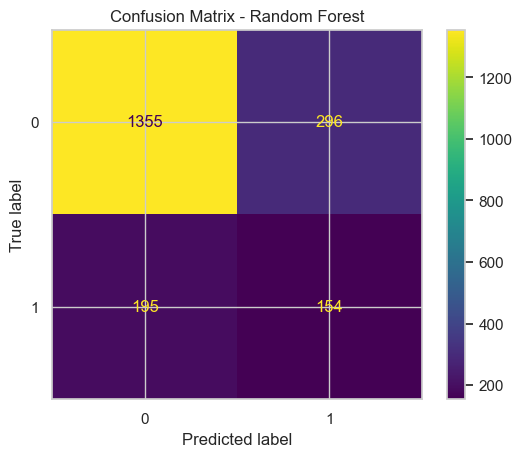

Best model: Random Forest


In [11]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print("Best model:", best_model_name)

## 11. ROC Curves

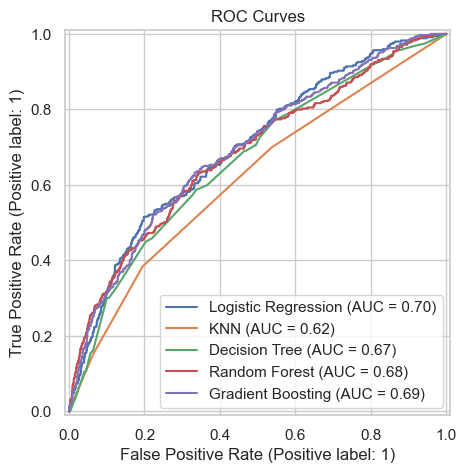

In [12]:
plt.figure(figsize=(7,5))
ax = plt.gca()

for name, pipe in trained_models.items():
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax)

plt.title("ROC Curves")
plt.show()

## 12. Feature Importance

Tree-based models are useful because they show which variables were important for prediction. This does not prove causality, but it helps interpret the model.

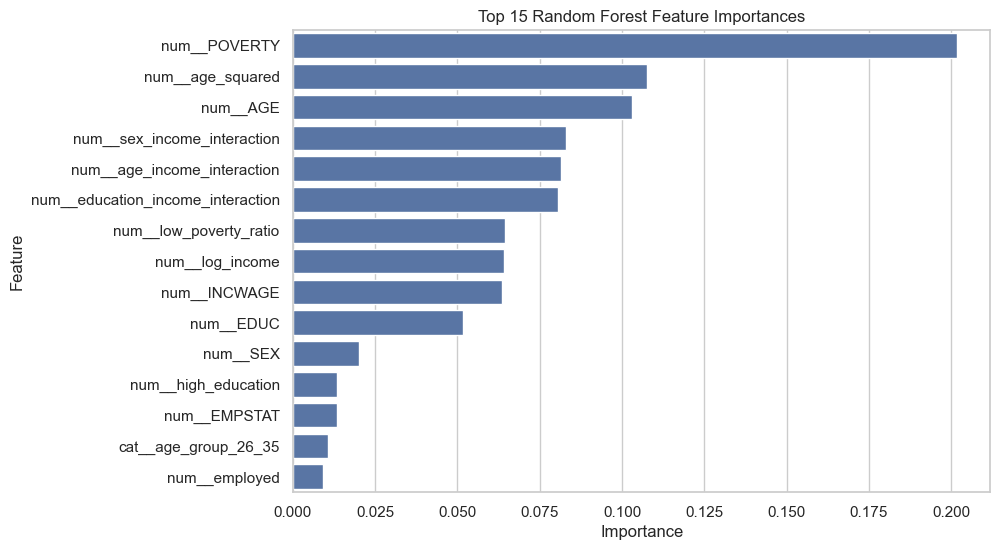

,feature,importance
10,num__POVERTY,0.201780
7,num__age_squared,0.107703
0,num__AGE,0.102931
12,num__sex_income_interaction,0.083054
13,num__age_income_interaction,0.081491
14,num__education_income_interaction,0.080647
11,num__low_poverty_ratio,0.064384
5,num__log_income,0.064064
4,num__INCWAGE,0.063411
2,num__EDUC,0.051674


In [13]:
rf_model = trained_models["Random Forest"]

# Get feature names after one-hot encoding
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

importance_df.head(15)

## 13. ML Summary

The machine learning results show that divorce status is difficult to predict perfectly from demographic variables alone. This makes sense because divorce is affected by many personal and social factors that are not fully captured in census data. Still, the models find useful patterns from age, income, education, employment, poverty/work variables when available, and engineered interaction features.

I compared Logistic Regression, KNN, Decision Tree, Random Forest, and Gradient Boosting models. Logistic Regression is useful as a baseline model, while KNN and tree-based models provide additional comparison and help capture more complex relationships in the data. Random Forest and Gradient Boosting add more depth to the analysis because they can model non-linear relationships better than a simple linear classifier.

Since the target variable is imbalanced, I focused more on F1 score, recall, ROC-AUC, and confusion matrices instead of relying only on accuracy.